In [1]:
# https://drive.google.com/file/d/10cyq2pvGMaHnCXR0rolTUwQ8TgsHKiEC/view?usp=sharing ?

#!gdown --id 10cyq2pvGMaHnCXR0rolTUwQ8TgsHKiEC -O vp.jpg


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib notebook

img = cv2.imread('vp.jpg')
# cv2_imshow(img)

In [3]:
def norm_points(p):
    r,c = p.shape
    for i in range(c):
        if p[-1,i] != 0:
            p[:,i] /= p[-1,i]
    return p

In [17]:
#Definimos los puntos ideales de la reticula

pr = np.ones((3,4))
#pr[:2,0] = [0., 5.]
#pr[:2,1] = [0., 0.]
#pr[:2,2] = [2.8, 0.]
#pr[:2,3] = [2.8, 5.]
pr[:2,0] = [0., 1]
pr[:2,1] = [0., 0.]
pr[:2,2] = [1, 0.]
pr[:2,3] = [1, 1.]

pr = norm_points(pr)

print("pr =\n", pr)

#Estas son las lineas de la reticula que pasan por los puntos pr.
lr = np.ones((3,4))
lr[:,0] = np.cross(pr[:,0], pr[:,1])
lr[:,1] = np.cross(pr[:,1], pr[:,2])
lr[:,2] = np.cross(pr[:,2], pr[:,3])
lr[:,3] = np.cross(pr[:,3], pr[:,0])


print("lr =\n", lr)

pr =
 [[0. 0. 1. 1.]
 [1. 0. 0. 1.]
 [1. 1. 1. 1.]]
lr =
 [[ 1.  0. -1.  0.]
 [ 0.  1.  0. -1.]
 [ 0.  0.  1.  1.]]


In [18]:

# Definir puntos de fuga y puntos
vp1 = np.array([-3, 540, 1])
vp2 = np.array([1916, 540, 1])

p1 = np.array([114, 766, 1])
p2 = np.array([829, 677, 1])
p3 = np.array([1019, 710, 1])

blue_points = [p1, p2, p3]

# Calcular líneas
l = np.zeros((3, 4))
l[:, 0] = np.cross(vp1, p2)
l[:, 1] = np.cross(vp1, p1)
l[:, 2] = np.cross(vp2, p1)
l[:, 3] = np.cross(vp2, p3)

def norm_points(p):
    return p / p[-1]

# Calcular punto de intersección p4
p4 = np.cross(l[:, 1], l[:, 3])
p4 = norm_points(p4)

# Almacenar puntos en la matriz p
p = np.zeros((3, 4))
p[:, 0] = p1
p[:, 1] = p2
p[:, 2] = p3
p[:, 3] = p4
p = norm_points(p)

# Dibujar puntos de fuga (rojo)
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 0, 255), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 0, 255), -1)

# Dibujar puntos azules
for i, point in enumerate(blue_points):
    cv2.circle(img, (point[0], point[1]), 5, (255, 0, 0), -1)
    cv2.putText(img, f'p{i+1}', (point[0] + 10, point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

cv2.circle(img, (int(p4[0]), int(p4[1])), 5, (0, 255, 255), -1)  # Dibujar p4 (amarillo)
cv2.putText(img, 'p4', (int(p4[0]) + 10, int(p4[1]) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

# Función para calcular intersección de una línea con los bordes de la imagen
def get_line_endpoints(line, width, height):
    x0, y0, w0 = np.cross(line, [1, 0, 0])  # Intersección con x=0
    x1, y1, w1 = np.cross(line, [1, 0, -width])  # Intersección con x=width
    y0, x0 = y0 / w0, x0 / w0
    y1, x1 = y1 / w1, x1 / w1
    return (int(x0), int(y0)), (int(x1), int(y1))

# Dibujar líneas
for i in range(4):
    pt1, pt2 = get_line_endpoints(l[:, i], img.shape[1], img.shape[0])
    color = (0, 255, 0)
    cv2.line(img, pt1, pt2, color, 2)
    mid_x, mid_y = (pt1[0] + pt2[0]) // 2, (pt1[1] + pt2[1]) // 2
    cv2.putText(img, f'l{i+1}', (mid_x, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)




Compute the transformation that maps the projective space into and affine one.

In [19]:
def proj2Affine(Vp1, Vp2):
  """
  This function defines a homography that maps the points that lie on the line
  defined by the homogeneous 2D points Vp1 and Vp2 to a line at the infinity

  Parameters:

  Vp1, Vp2: 3x1 matrices, that represents homogenous 2D points.

  Returns a 3x3 matrix that represents the mapping homography.

  First we compute the equation of the line where Vp1 and Vp2 lies.
  """
  m = np.array([[Vp1[0], Vp1[1]], [Vp2[0], Vp2[1]]])
  b = np.array([-1, -1])
  l = np.ones(3)
  l[:2] = np.linalg.solve(m, b)
  # Define H according to formula in Hartley & Zisserman "Multiple View Geometry"
  # 2nd edition, section 2.7.2, pp 49
  H = np.eye(3)
  H[2, :] = l.T
  return H

In [20]:
H = proj2Affine(vp1, vp2)
H

array([[ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        ],
       [ 0.        , -0.00185185,  1.        ]])

The mapping that maps lines is defined in terms of the mapping of points.


In [21]:
Hl = np.linalg.inv(H).T
Hl

array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.00185185],
       [0.        , 0.        , 1.        ]])

% The computed lines are mapped into the affine space.


In [22]:
lp = np.dot(Hl, l)
#lp = norm_points(lp)
print(lp.shape)
print(np.dot(lp[:,0],lp[:,1])/(np.linalg.norm(lp[:,0])*np.linalg.norm(lp[:,1])))

print(np.dot(lp[:,2],lp[:,3])/(np.linalg.norm(lp[:,2])*np.linalg.norm(lp[:,3])))


print(np.dot(lp[:,1],lp[:,2])/(np.linalg.norm(lp[:,1])*np.linalg.norm(lp[:,2])))

print(np.dot(lp[:,0],lp[:,3])/(np.linalg.norm(lp[:,0])*np.linalg.norm(lp[:,3])))

print(lp[:,0])
print(lp[:,1])
print(lp[:,2])
print(lp[:,3])

(3, 4)
0.9999947690615424
0.9999999836047072
-0.9999930040931201
-0.9999995917010942
[-1.37000000e+02 -7.61111111e-01 -4.49691000e+05]
[-2.26000000e+02 -1.25555556e+00 -6.38580000e+04]
[-2.26000000e+02  8.01881481e+02  1.40609600e+06]
[-1.70000000e+02  6.03185185e+02  8.10100000e+05]


The points that intersect the lines in the affine space are compute and normalized.

In [23]:
pp = np.ones((3, 4))
pp[:, 0] = np.cross(lp[:, 1], lp[:, 2])
pp[:, 1] = np.cross(lp[:, 0], lp[:, 2])
pp[:, 2] = np.cross(lp[:, 0], lp[:, 3])
pp[:, 3] = np.cross(lp[:, 1], lp[:, 3])

pp = norm_points(pp)

pp

array([[-2.72389381e+02, -3.26755820e+03, -3.26983496e+03,
        -2.74666144e+02],
       [-1.83026549e+03, -2.67441536e+03, -2.26459797e+03,
        -1.42044809e+03],
       [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00]])

<IPython.core.display.Javascript object>


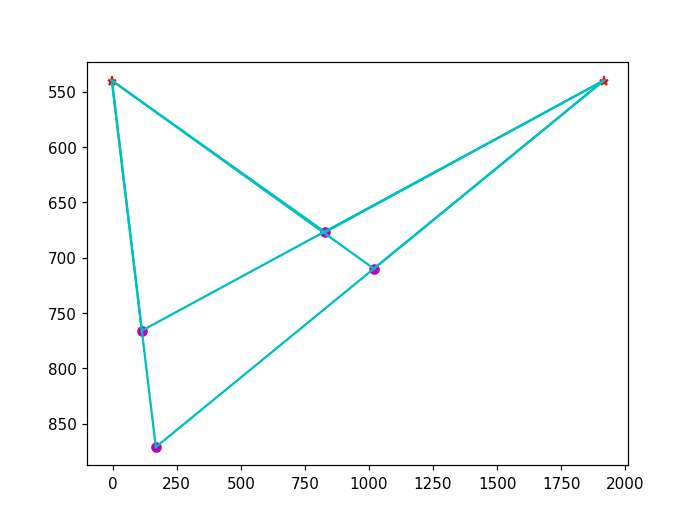

In [24]:
fig1,ax1 = plt.subplots()
ax1.plot(vp1[0],vp1[1],"r*",vp2[0],vp2[1],"r*")
ax1.plot(p[0,0],p[1,0],'om',p[0,1],p[1,1],'om',p[0,2],p[1,2],'om',p[0,3],p[1,3],'om')
ax1.plot(np.array([vp1[0], p[0,0]]), np.array([vp1[1], p[1,0]]),'c')
ax1.plot(np.array([vp1[0], p[0,1]]), np.array([vp1[1], p[1,1]]),'c')
ax1.plot(np.array([vp2[0], p[0,1]]), np.array([vp2[1], p[1,1]]),'c')
ax1.plot(np.array([vp2[0], p[0,2]]), np.array([vp2[1], p[1,2]]),'c')
ax1.plot(np.array([vp1[0], p[0,3]]), np.array([vp1[1], p[1,3]]),'c')
ax1.plot(np.array([vp1[0], p[0,2]]), np.array([vp1[1], p[1,2]]),'c')
ax1.plot(np.array([vp2[0], p[0,0]]), np.array([vp2[1], p[1,0]]),'c')
ax1.plot(np.array([vp2[0], p[0,3]]), np.array([vp2[1], p[1,3]]),'c')
ax1.invert_yaxis()

<IPython.core.display.Javascript object>


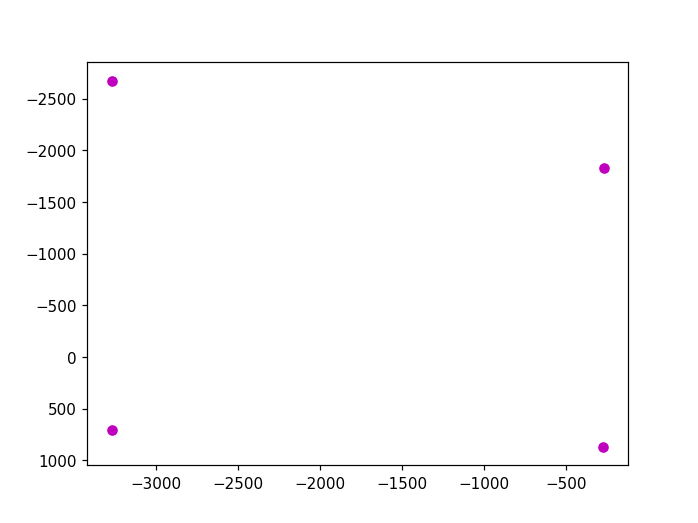

In [25]:
fig2,ax2 = plt.subplots()

ax2.plot(pp[0,0],pp[1,0],'om',pp[0,1],pp[1,1],'om',pp[0,2],p[1,2],'om',pp[0,3],p[1,3],'om')

ax2.invert_yaxis()

Homography Matrix:
[[ 1.34581773e+00 -7.60896838e+02  8.29000000e+02]
 [-9.84469769e+01 -2.19394541e+02  6.77000000e+02]
 [-1.85136587e-01 -4.02603839e-01  1.00000000e+00]]


<IPython.core.display.Javascript object>


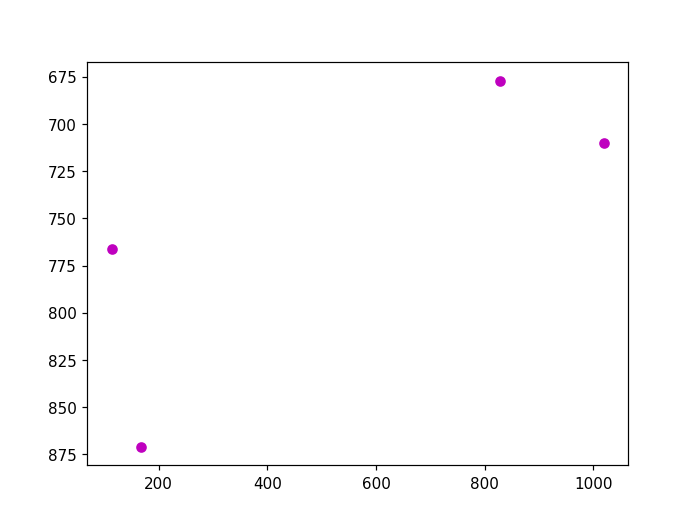

(array([[1.14000000e+02, 8.29000000e+02, 1.01900000e+03, 1.68459351e+02],
        [7.66000000e+02, 6.77000000e+02, 7.10000000e+02, 8.71195007e+02],
        [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]),
 array([[-1.59545099e-04,  3.25851905e-04, -2.09850648e-04,
          3.53910344e-03],
        [-1.28173872e-03, -1.87611703e-03, -1.10727069e-03,
         -1.83219033e-03],
        [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
          1.00000000e+00]]))

In [26]:
# Define the source and destination points for the homography
src_pts = np.float32([pr[:, 0], pr[:, 1], pr[:, 2], pr[:, 3]])
dst_pts = np.float32([p[:, 0], p[:, 1], p[:, 2], p[:, 3]])


# Find the homography matrix
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)

# Print the homography matrix
print("Homography Matrix:")
print(M)

pm = np.dot(M, pr)
pm = norm_points(pm)

lm = np.dot (np.linalg.inv(M.T), lr)
lm = norm_points(lm)



fig3,ax3 = plt.subplots()

ax3.plot(pm[0,0],pm[1,0],'om',pm[0,1],pm[1,1],'om',pm[0,2],pm[1,2],'om',pm[0,3],pm[1,3],'om')

ax3.invert_yaxis()

pm,lm

In [27]:
for i in range(4):
    point = [int(np.round(pm[0,i])), int(np.round(pm[1,i]))]
    cv2.circle(img, (point[0], point[1]), 8, (255, 0, 255), -1)
    cv2.putText(img, f'p{i+1}', (point[0] + 10, point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)


# Mostrar la imagen
cv2.namedWindow("Ventana1", cv2.WINDOW_NORMAL)
cv2.imshow("Ventana1",img)
cv2.waitKey(0)


27

In [28]:
cv2.destroyAllWindows()

In [29]:
M.T,M

(array([[ 1.34581773e+00, -9.84469769e+01, -1.85136587e-01],
        [-7.60896838e+02, -2.19394541e+02, -4.02603839e-01],
        [ 8.29000000e+02,  6.77000000e+02,  1.00000000e+00]]),
 array([[ 1.34581773e+00, -7.60896838e+02,  8.29000000e+02],
        [-9.84469769e+01, -2.19394541e+02,  6.77000000e+02],
        [-1.85136587e-01, -4.02603839e-01,  1.00000000e+00]]))